# Setup
To inspect the ensemble model and figure out why it produced weird MEIs

In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from openretina.models import *

### imports and vars

In [2]:
SESSION_DIR = "/gpfs01/euler/data/Data/Suhai/thesis/other_data/FloDeja/20251008/1/mei_GCL4"
OUTPUT_DIR = f"{SESSION_DIR}/GCL4_20251008_165030"
FIG_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/analysis_closed_loop_experiments/model_inspection"
COMPARISON_SESSION_ID = "session_1_ventral1_20200226"


# load model 
with open(f"{OUTPUT_DIR}/model_full.pt", "rb") as f:
    ensemble_model = torch.load(f,weights_only=False)

# metadata of model 
with open(f"{OUTPUT_DIR}/metadata.pkl", "rb") as f:
    metadata_ensemble = pickle.load(f)

# for completeness load mei_data_container.pkl too
with open(f"{OUTPUT_DIR}/mei_data_container.pkl", "rb") as f:
    mei_data_container = pickle.load(f)

# single model from openretia 
or_model = load_core_readout_from_remote("hoefling_2024_base_low_res", "cuda")

# unpack some metadata
metadata_ensemble.keys()
roi_ids2readout_idx = metadata_ensemble['roi_ids2readout_idx']
session_id = metadata_ensemble['new_session_id']
mask_means_precenter = metadata_ensemble["scaled_means_before_centering"]
ensemble_readouts_online_session = list(map(lambda member:member.readout[session_id], ensemble_model.members))



# som other info
n_members = len(ensemble_model.members)

green_channel = 0
uv_channel = 1

(1, 2, 50, 18, 16)

In [10]:
or_model.forward(torch.rand(or_model.stimulus_shape(time_steps= 50)))

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

### helpers

In [110]:
def save_all_kernels(single_model, 
                     base_dir,
                     new_dir,skip_layers = []):
    """
    Save all convolutional kernels of a model as images."""
    layer_in_out_channels = ((2,16),(16,16))
    for layer_idx, (in_ch, out_ch) in enumerate(layer_in_out_channels):
        if layer_idx in skip_layers:
            continue
        for i in range(in_ch):
            for j in range(out_ch):
                conv_layer_figure = single_model.core.plot_weight_visualization(layer = layer_idx,in_channel = i,out_channel = j)
                save_path = os.path.join(base_dir, new_dir, f"layer{layer_idx}_in{i}_out{j}.png")
                os.makedirs(os.path.dirname(save_path), exist_ok=True)
                conv_layer_figure.savefig(save_path)
                plt.close(conv_layer_figure)
    

def show_weights_all_members(readout_idx,ensemble_readouts_online_session):
    for idx,member in enumerate(ensemble_readouts_online_session):
        weight_plot = member.plot_weight_for_neuron(readout_idx)

def fetch_mask_weights(readout_dx,readout):
    masks = readout.get_mask().detach().cpu().numpy()
    features = readout.features.detach().cpu().numpy()

    features_neuron = features[0, :, 0, readout_dx]
    mask_neuron = masks[readout_dx, :, :]
    return mask_neuron, features_neuron



# Why green asymmetry?

## visualize conv layers and readout weights both chaannels

In [69]:
save_all_kernels(or_model, FIG_DIR, "or_model_kernels")

In [71]:
save_all_kernels(ensemble_model.members[0], FIG_DIR, "ensemble_model_member0_kernels")

In [74]:
for member_idx, member_model in enumerate(ensemble_model.members):
    if member_idx == 0:
        continue
    save_all_kernels(member_model, FIG_DIR, f"ensemble_model_member{member_idx}_kernels",skip_layers=[1])

Okay so there seems not to bee much differnce looking at the first layer convolutional filters 

### readout weights 


In [90]:
sel_rois = [27,58,79] # the rois shown in the thesis
sel_readout_idxs = [roi_ids2readout_idx[roi] for roi in sel_rois]
print("Selected readout indices:", sel_readout_idxs)


for readout_idx in sel_readout_idxs:
    for idx,member in enumerate(ensemble_readouts_online_session):
        weight_plot = member.plot_weight_for_neuron(readout_idx)
        save_dir = os.path.join(FIG_DIR,"readout_weights")
        os.makedirs(save_dir, exist_ok=True)
        weight_plot.savefig(os.path.join(save_dir,f"ensemble_member{idx}_readoutidx{readout_idx}.png"))
        plt.close(weight_plot)


Selected readout indices: [7, 12, 15]


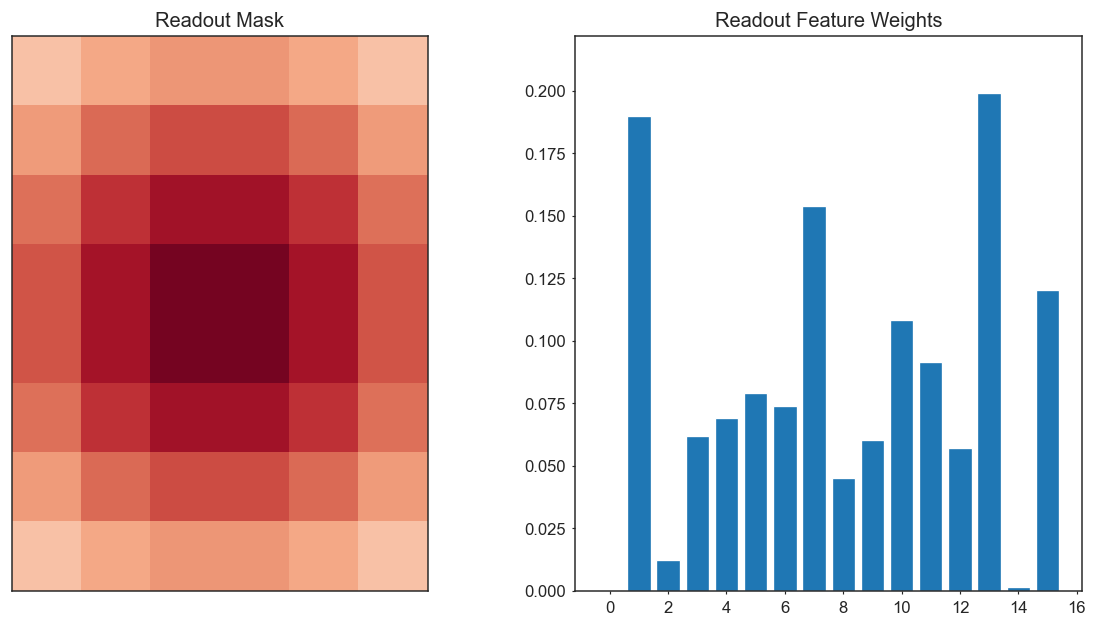

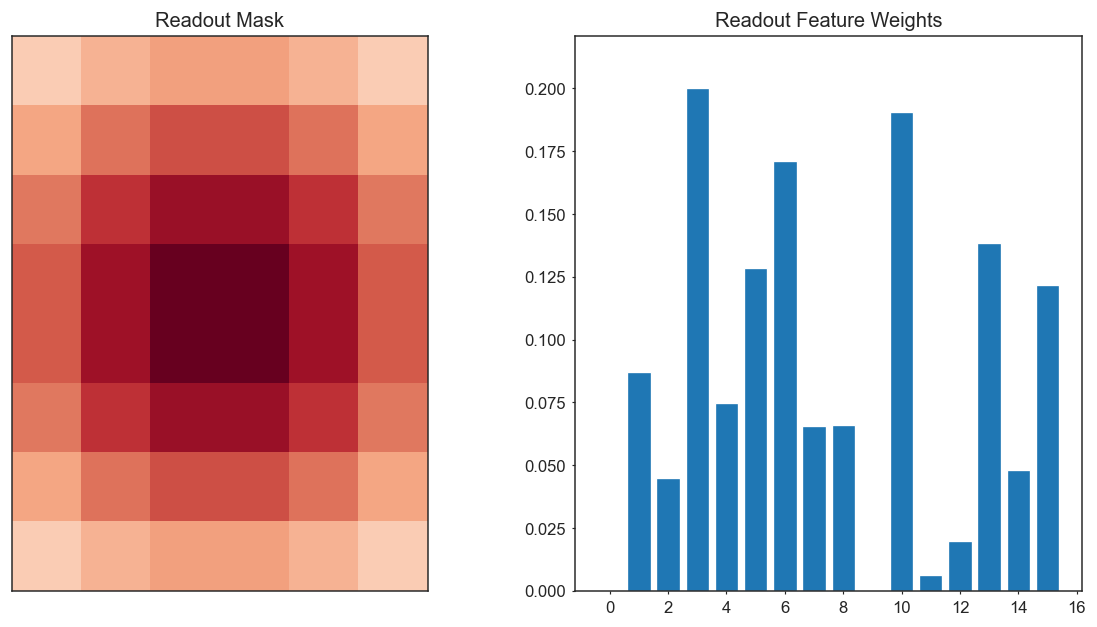

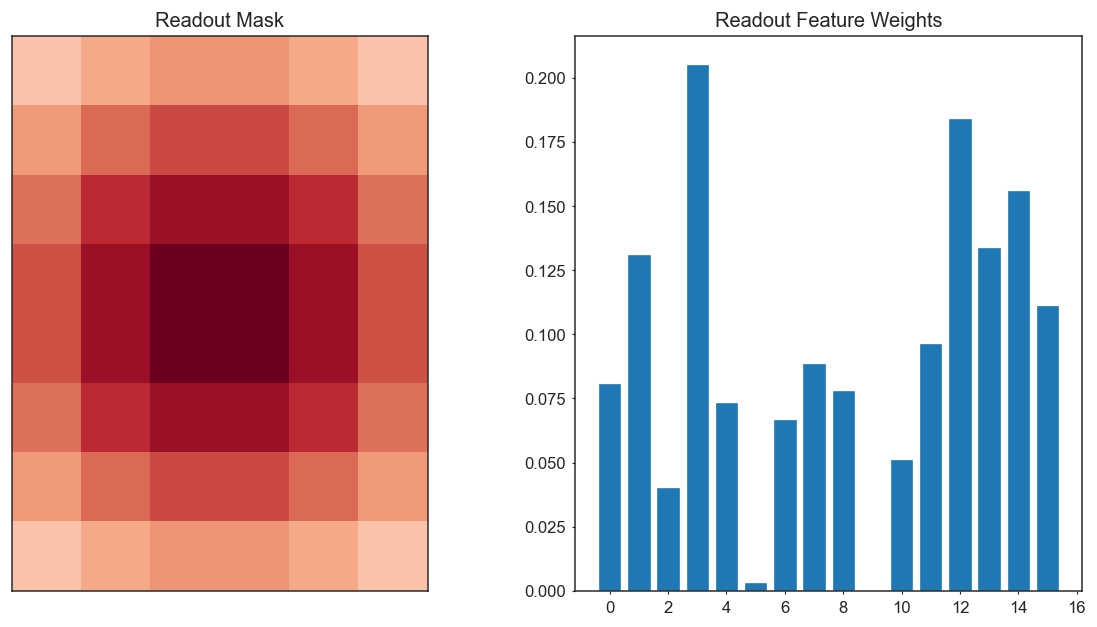

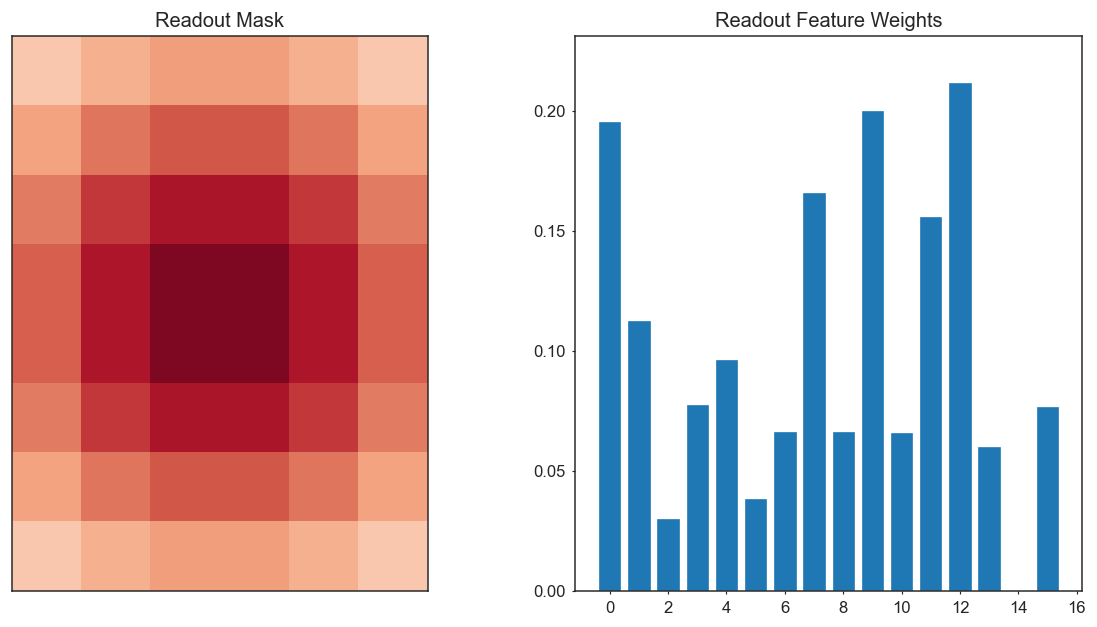

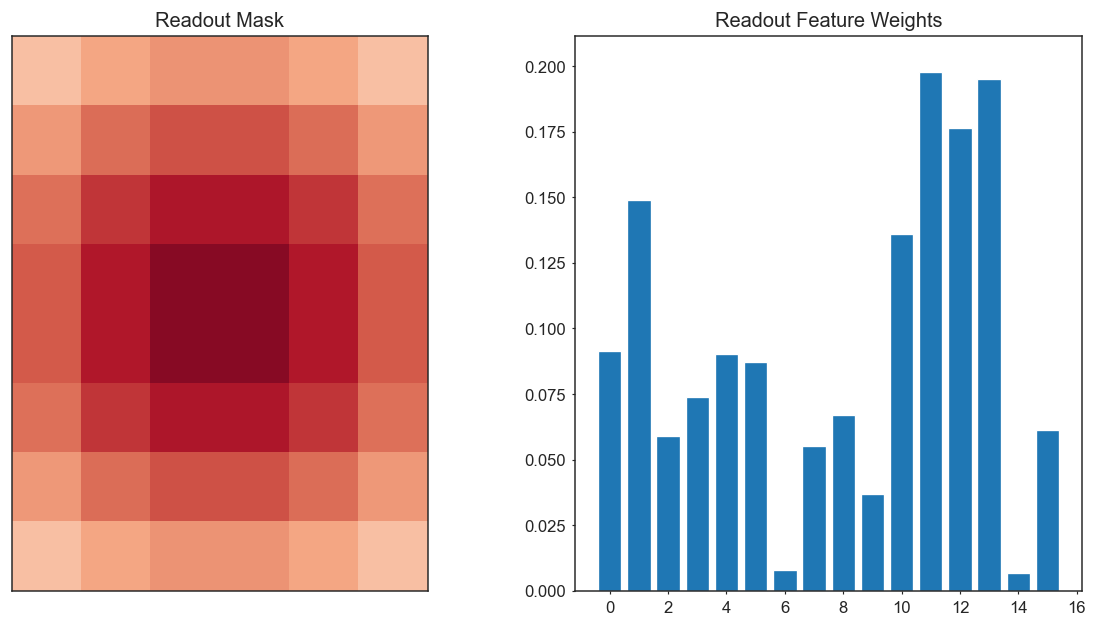

In [95]:

show_weights_all_members(sel_readout_idxs[0],ensemble_readouts_online_session)


- very large spatial mask
- very different readout weights per ensemble

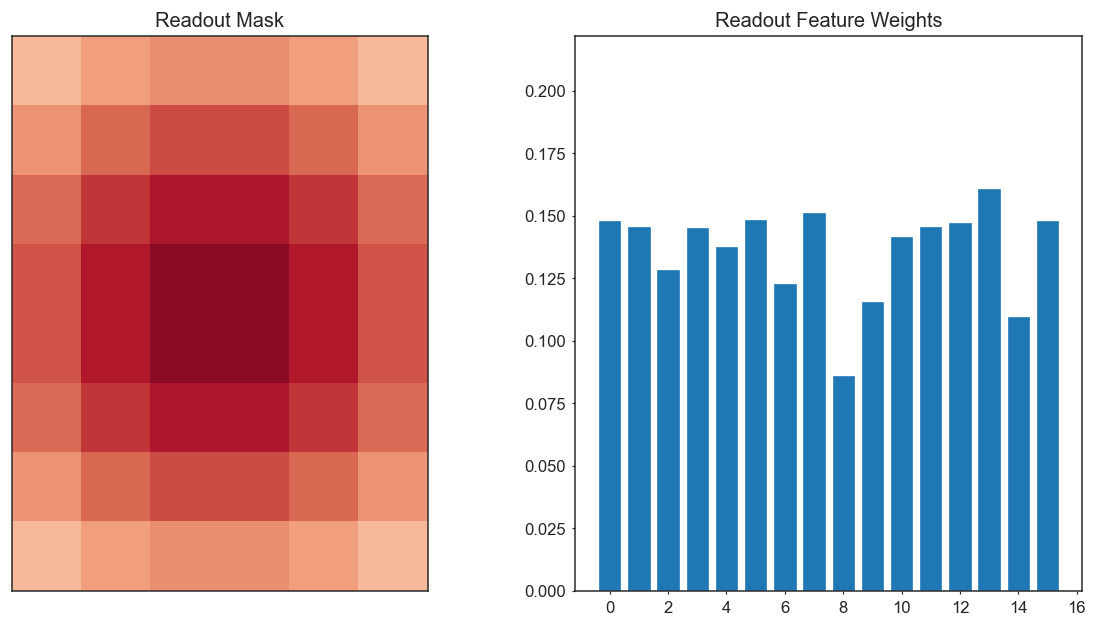

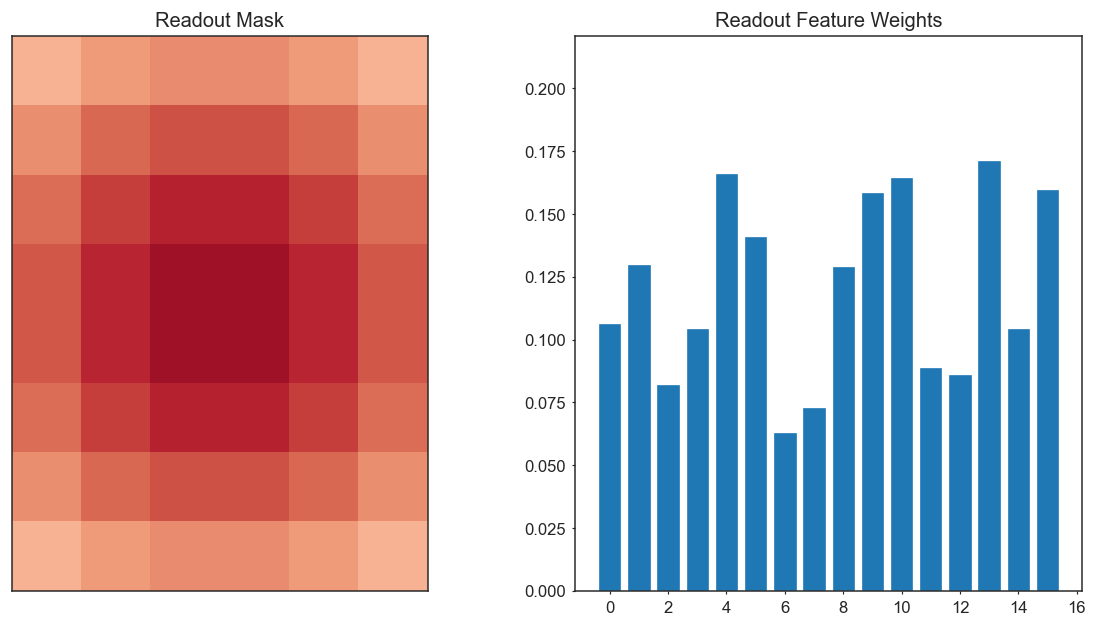

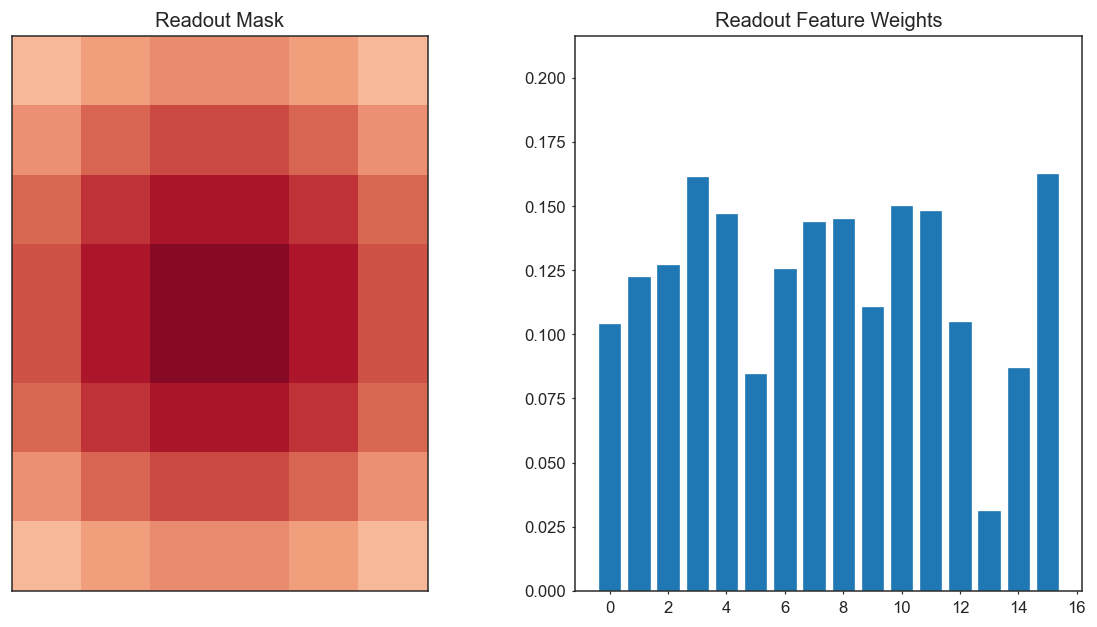

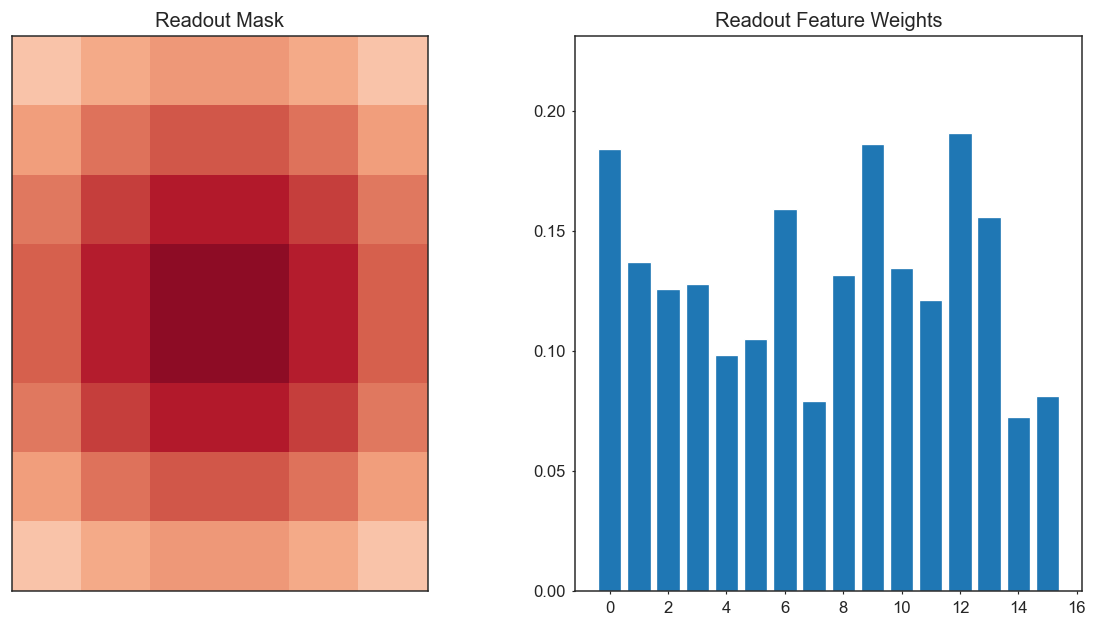

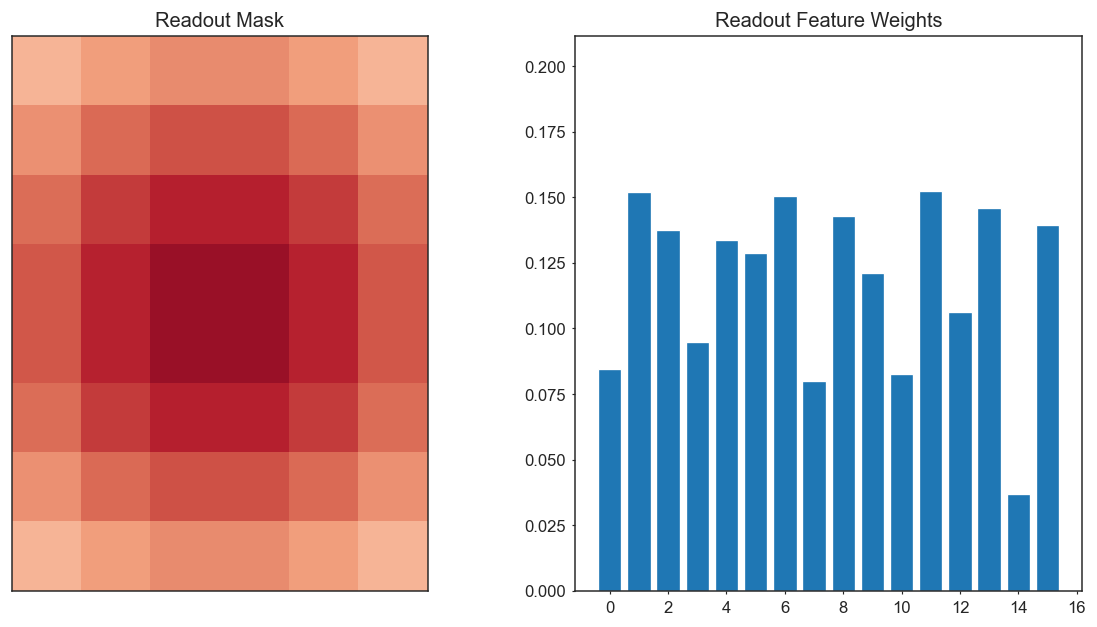

In [96]:
show_weights_all_members(sel_readout_idxs[1],ensemble_readouts_online_session)


- large variations again
- very equal weights in some 

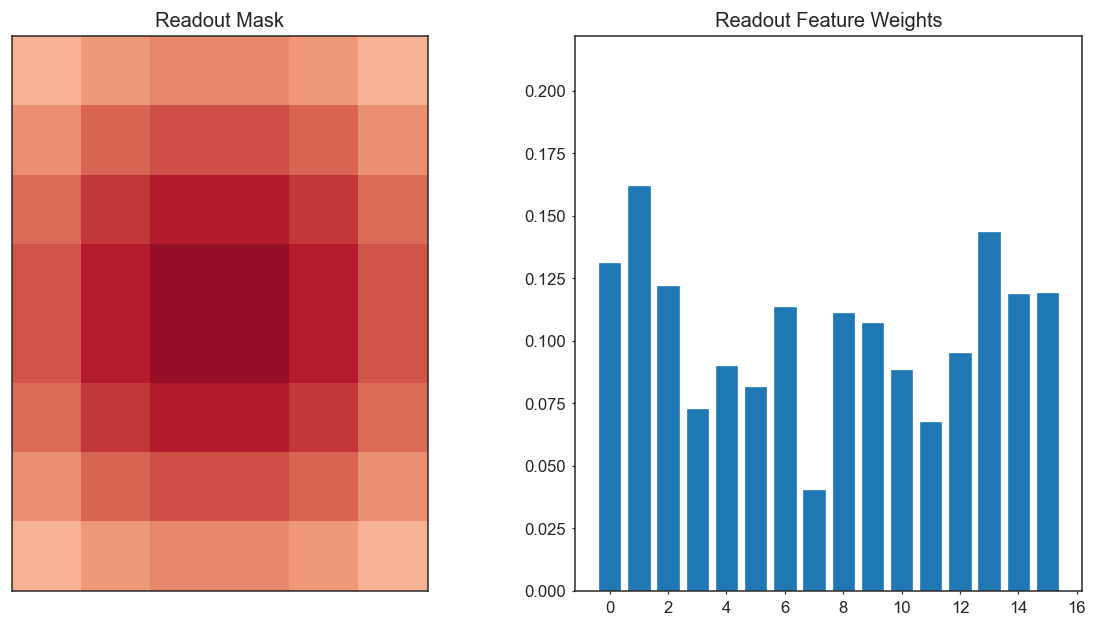

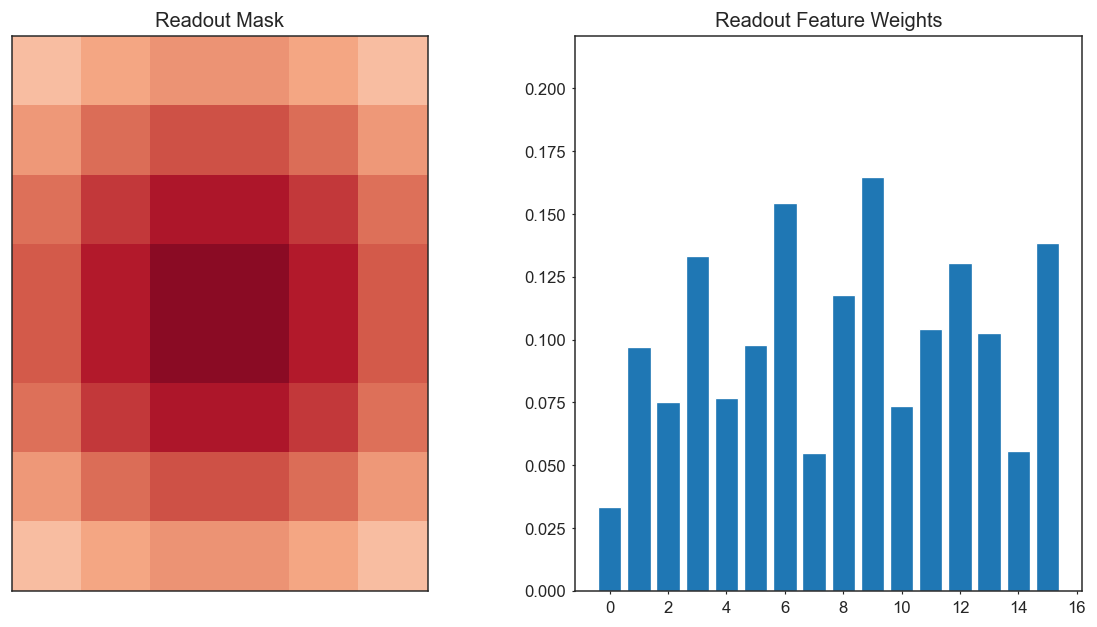

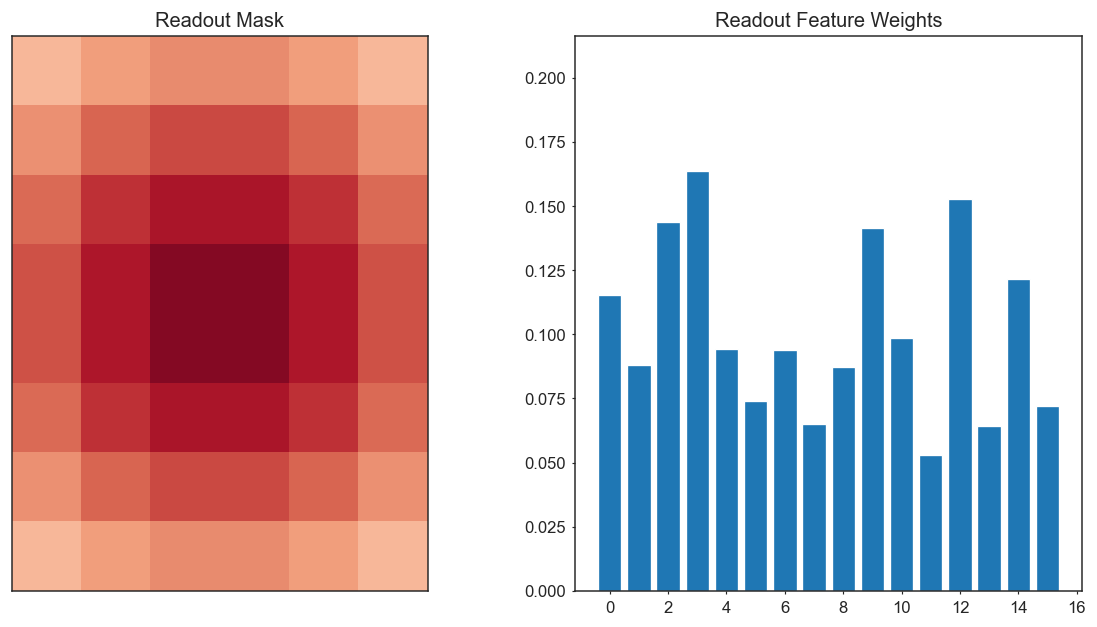

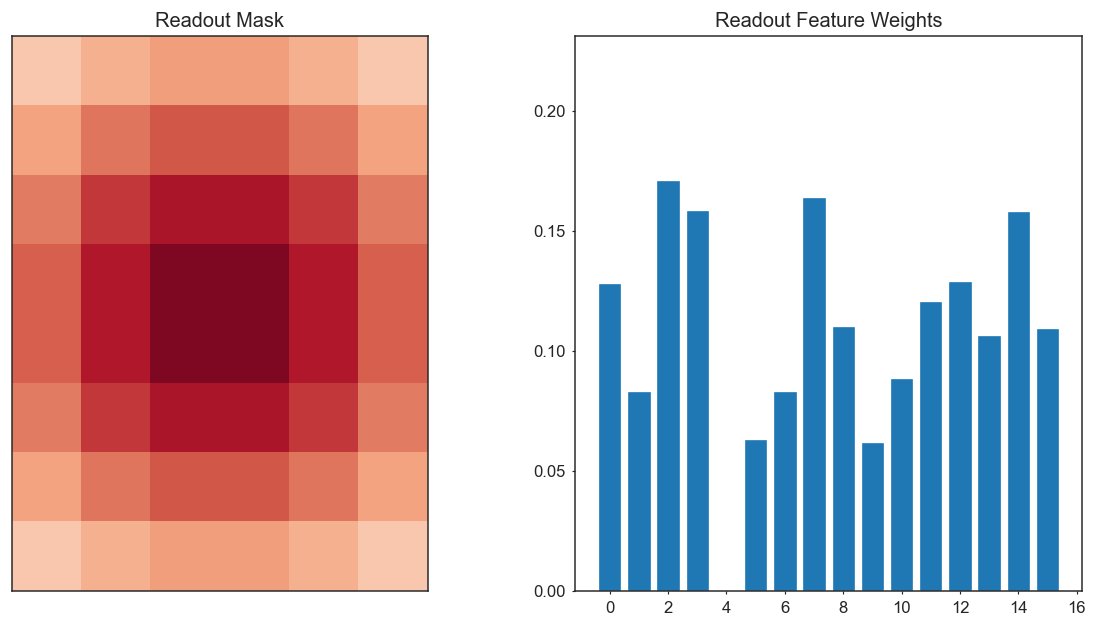

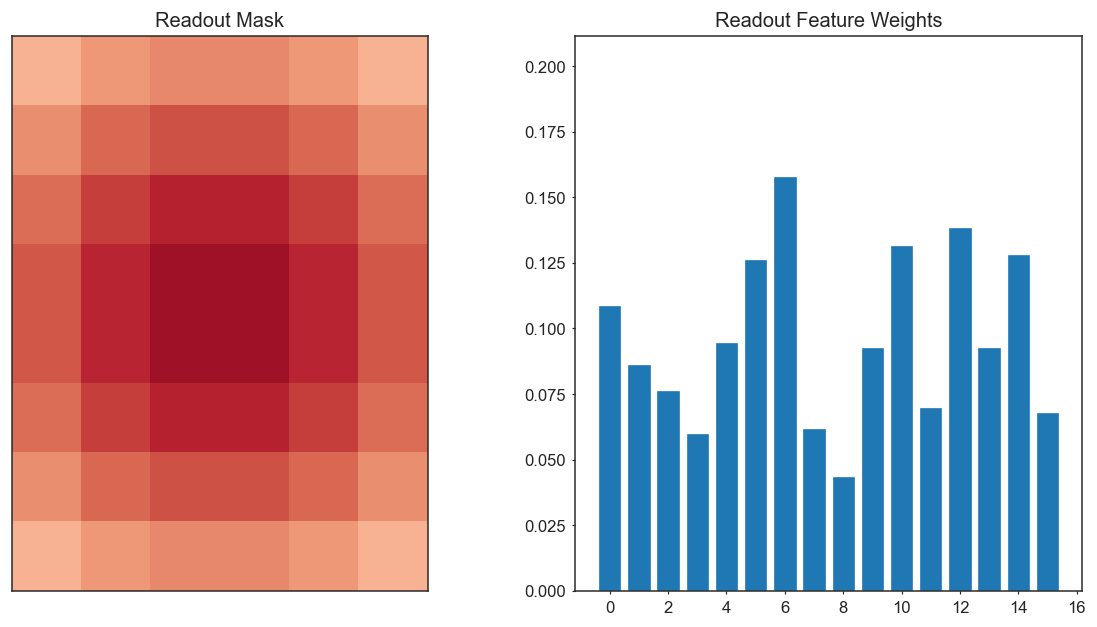

In [97]:
show_weights_all_members(sel_readout_idxs[2],ensemble_readouts_online_session)


0
5
10
15
20
25
30
35
40
45
50
55
60
65


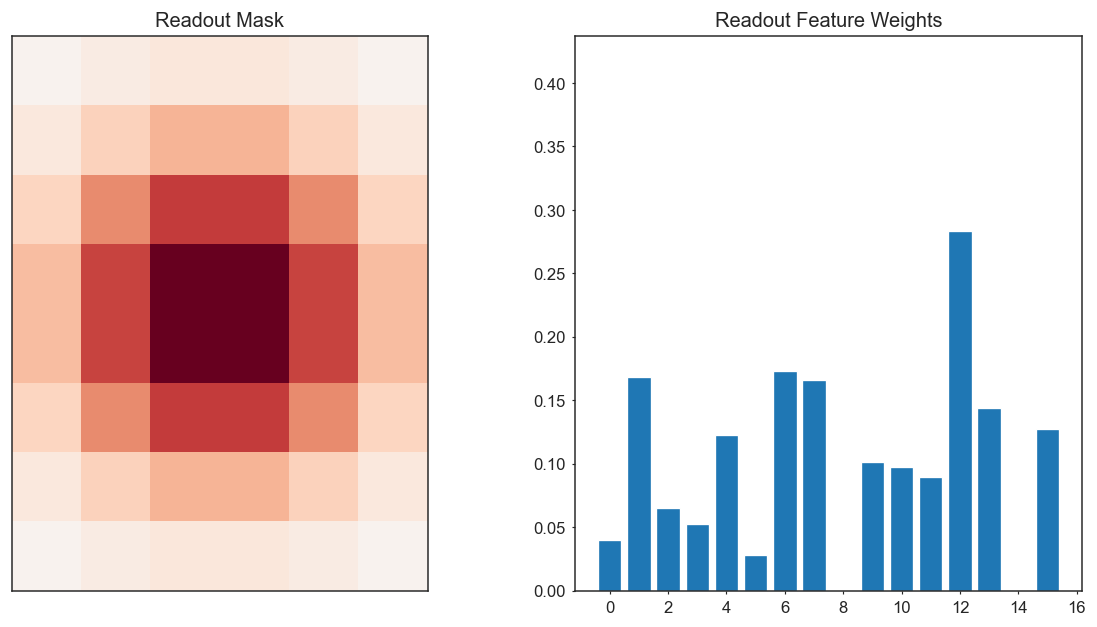

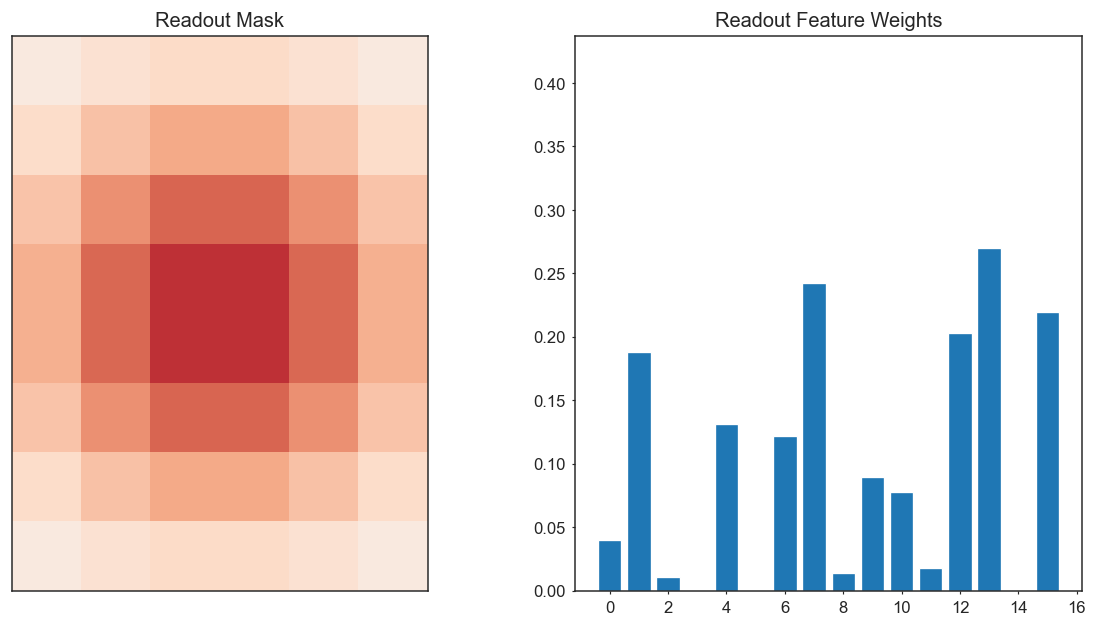

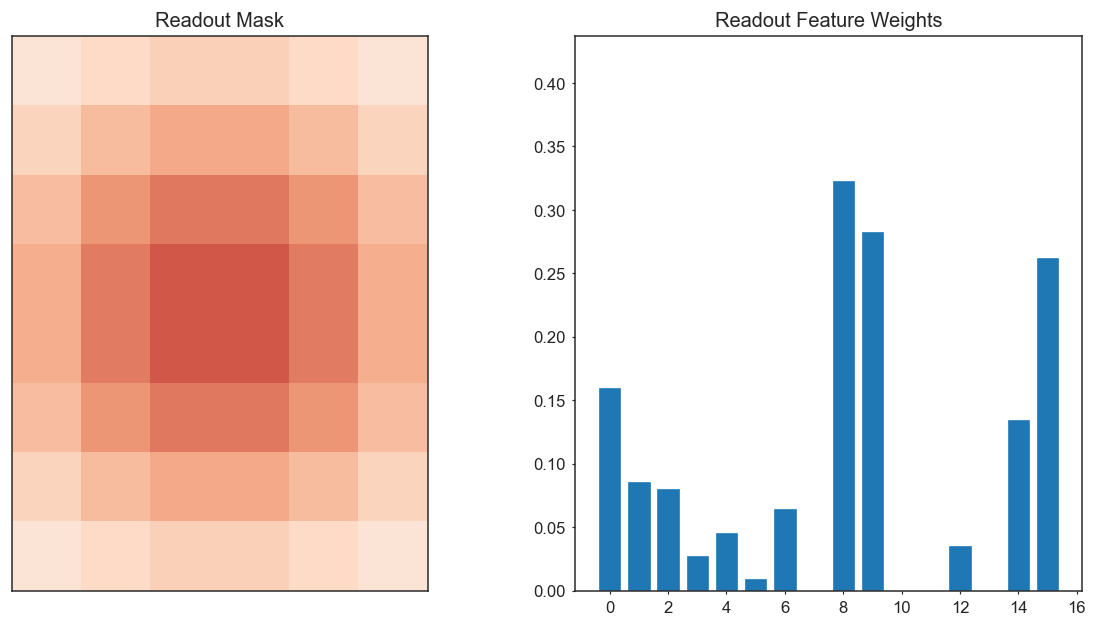

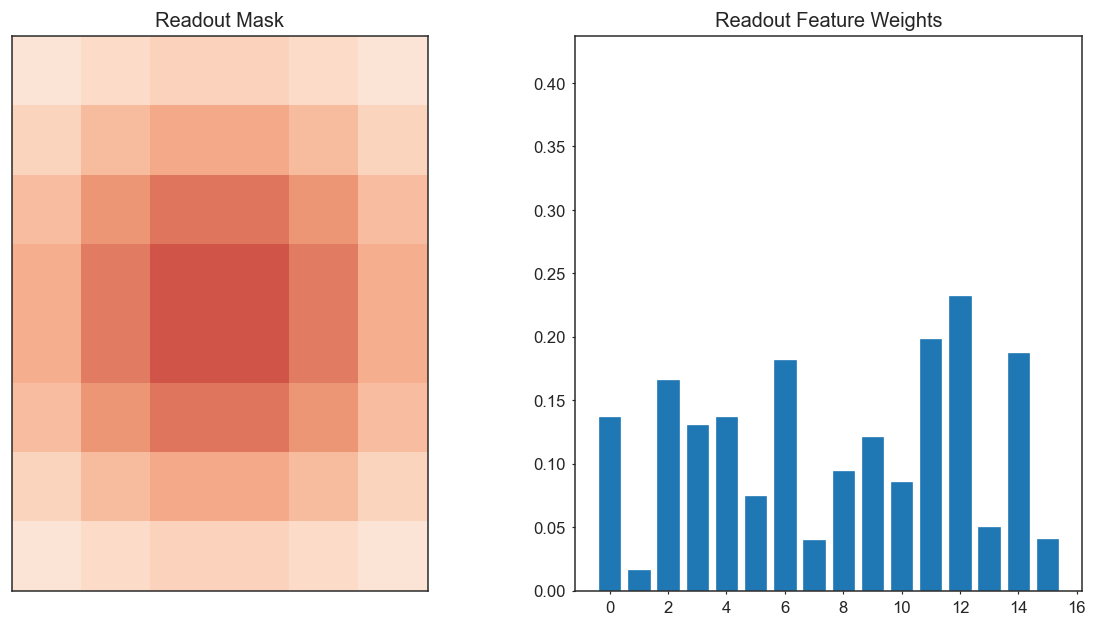

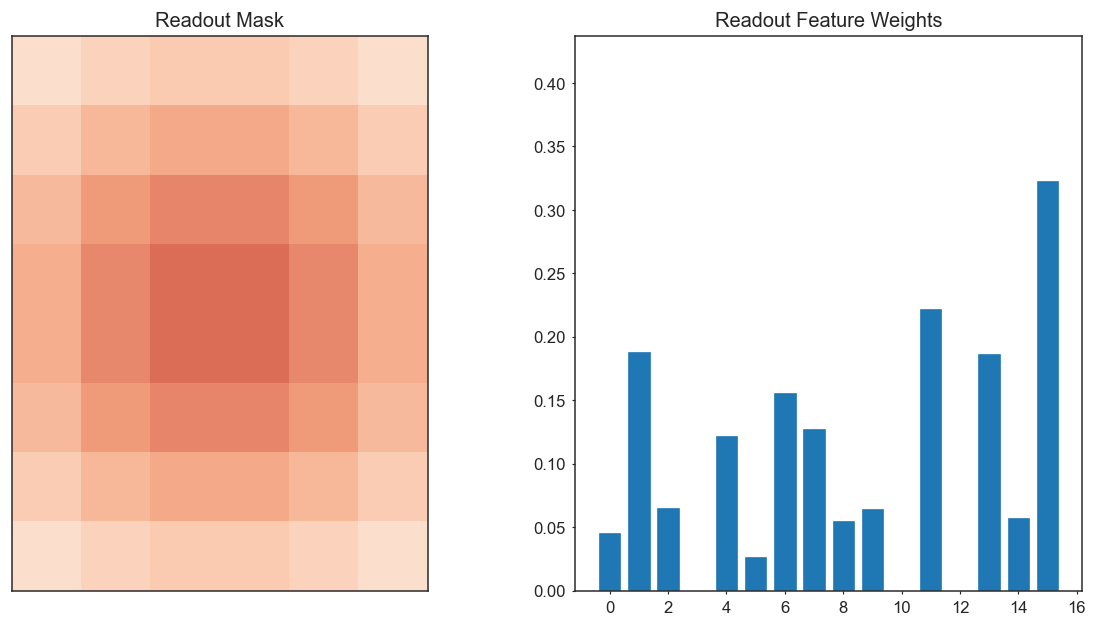

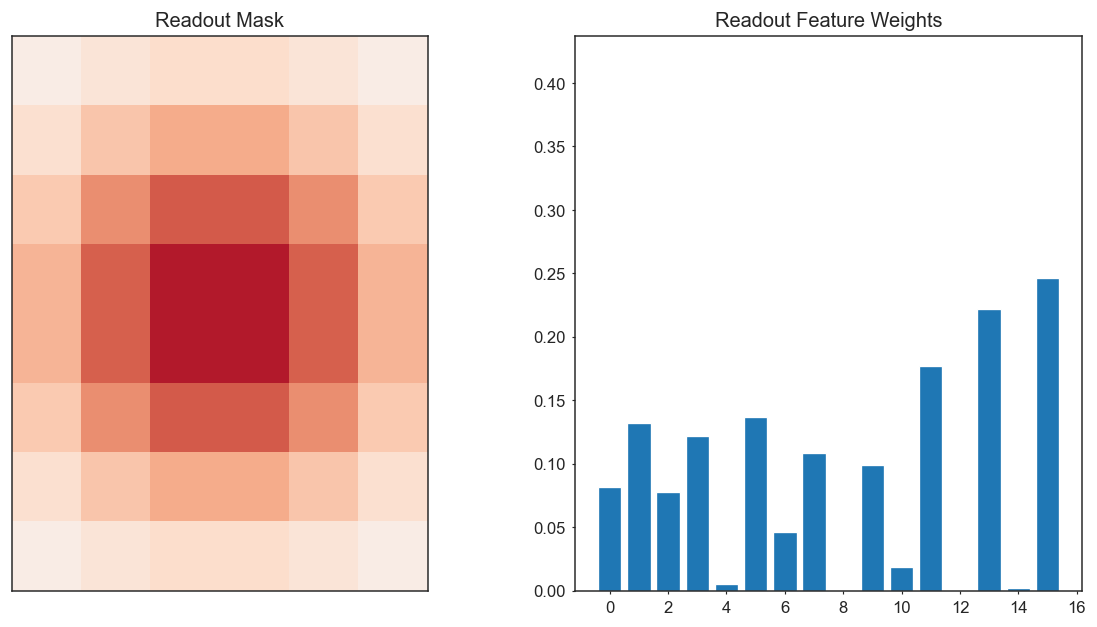

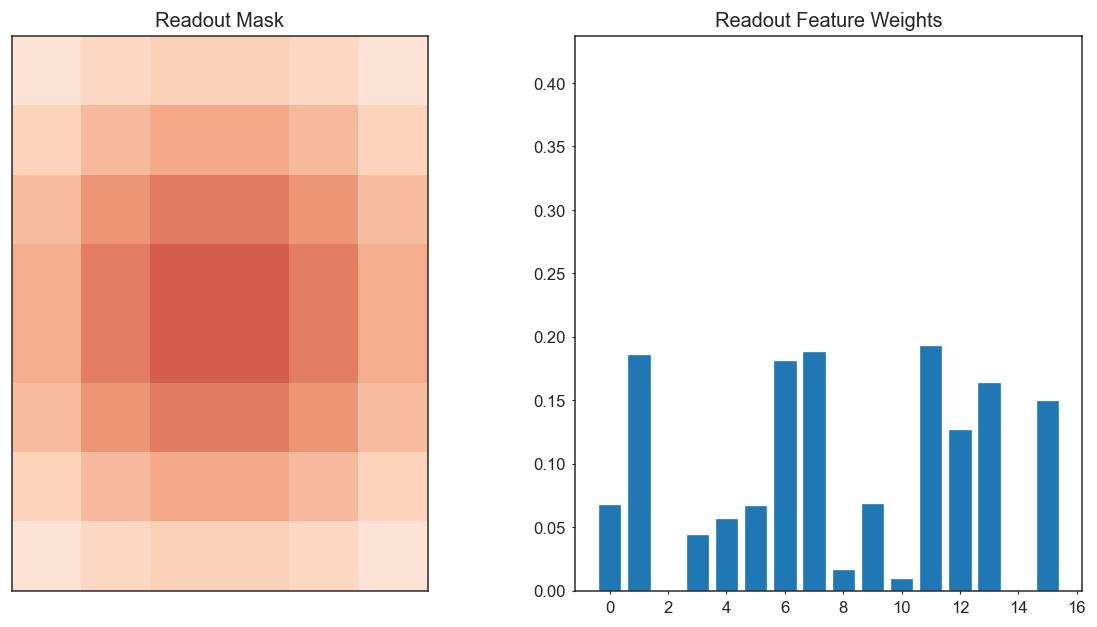

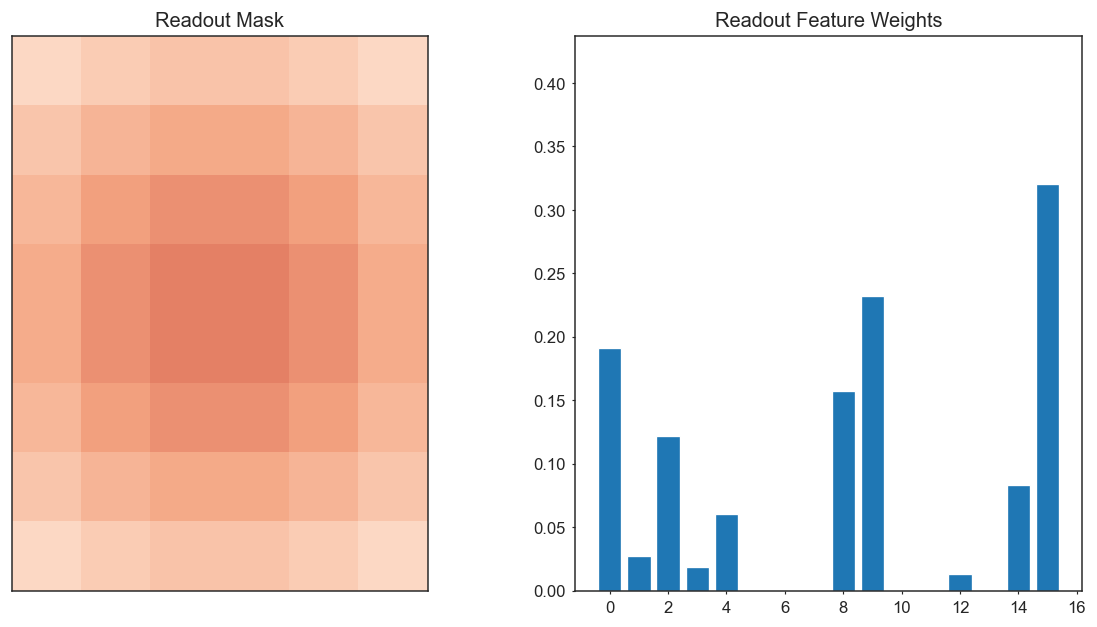

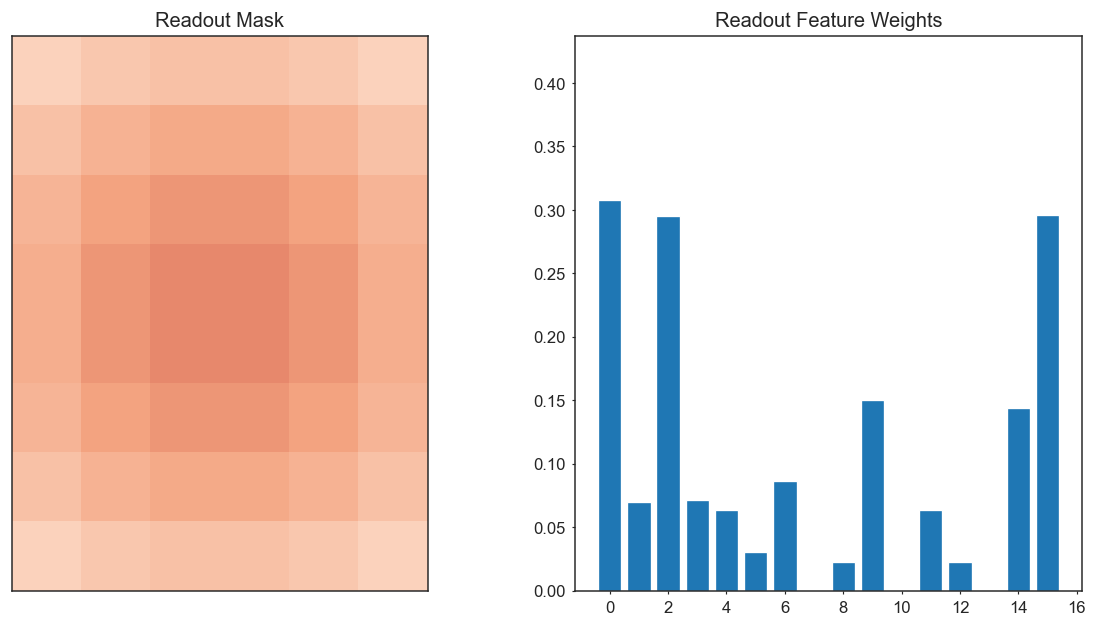

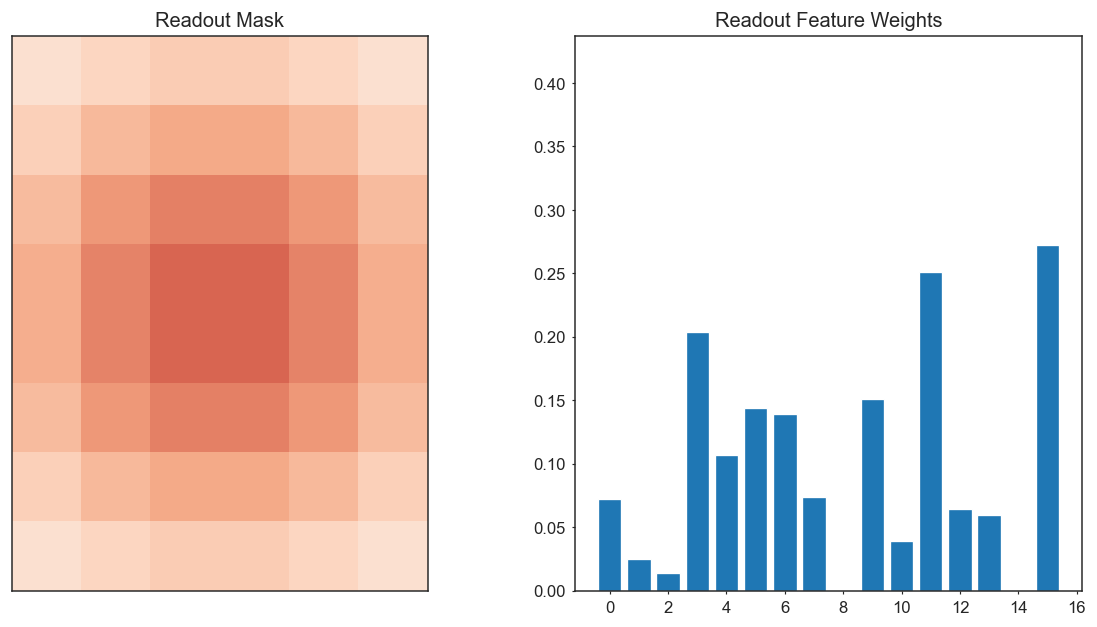

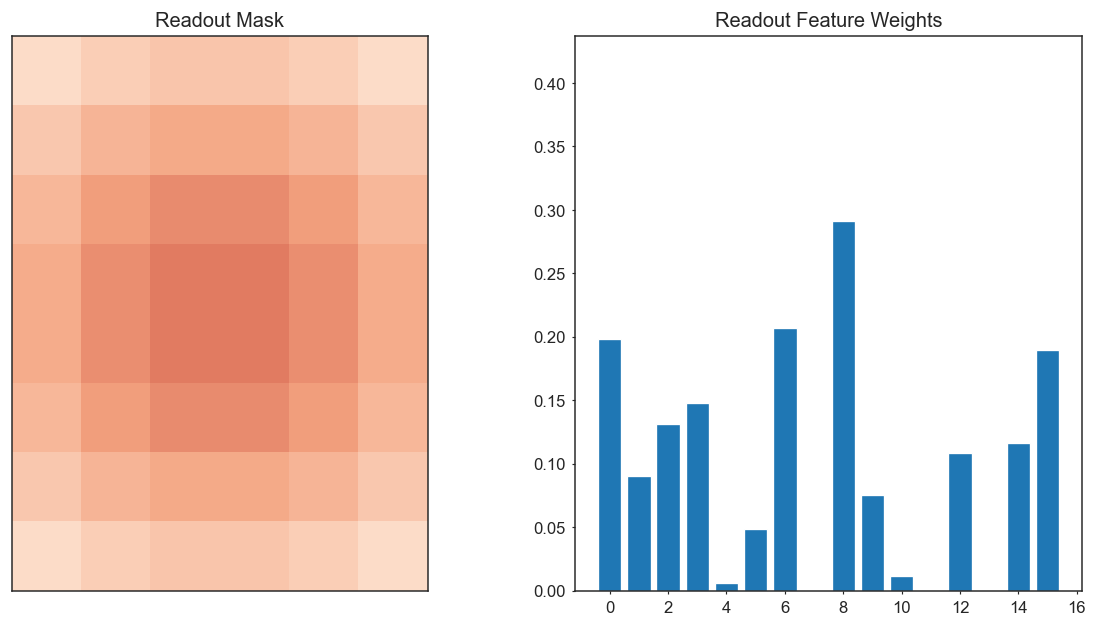

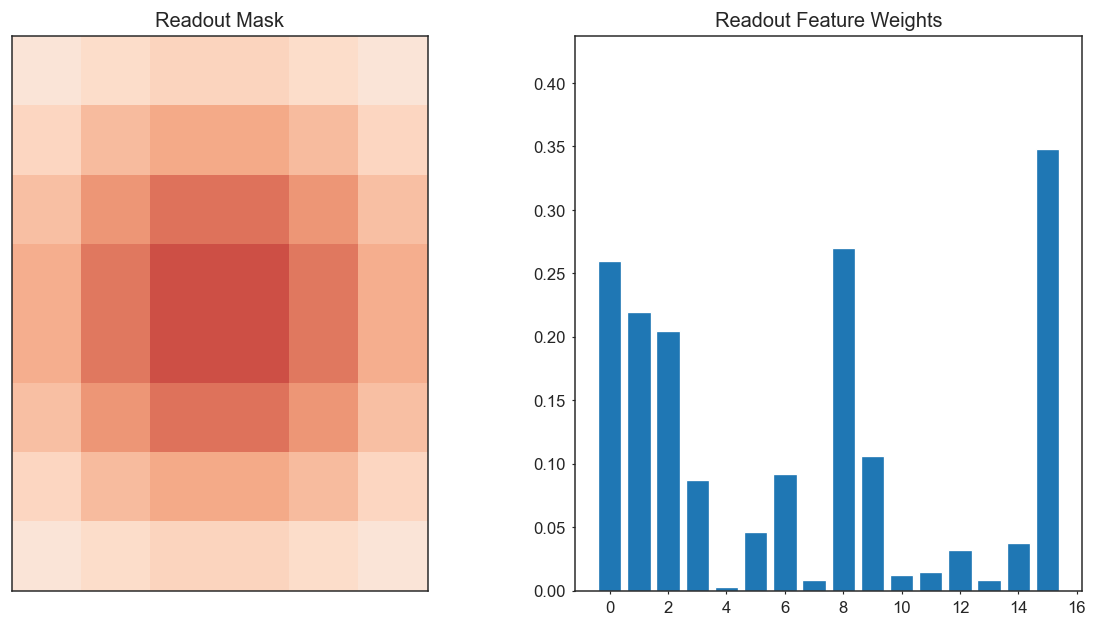

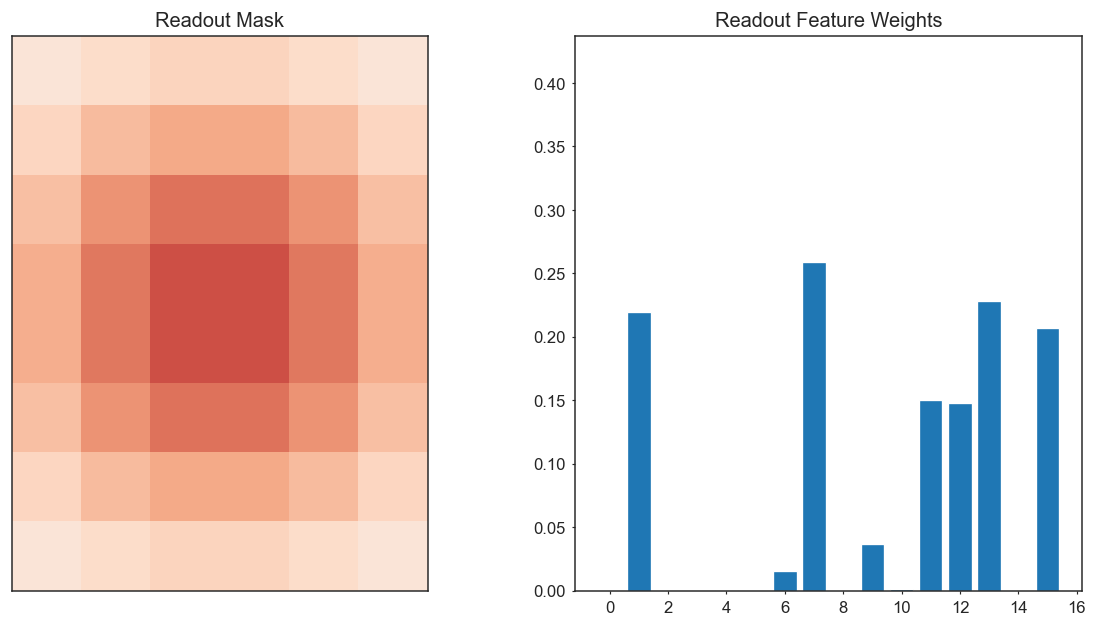

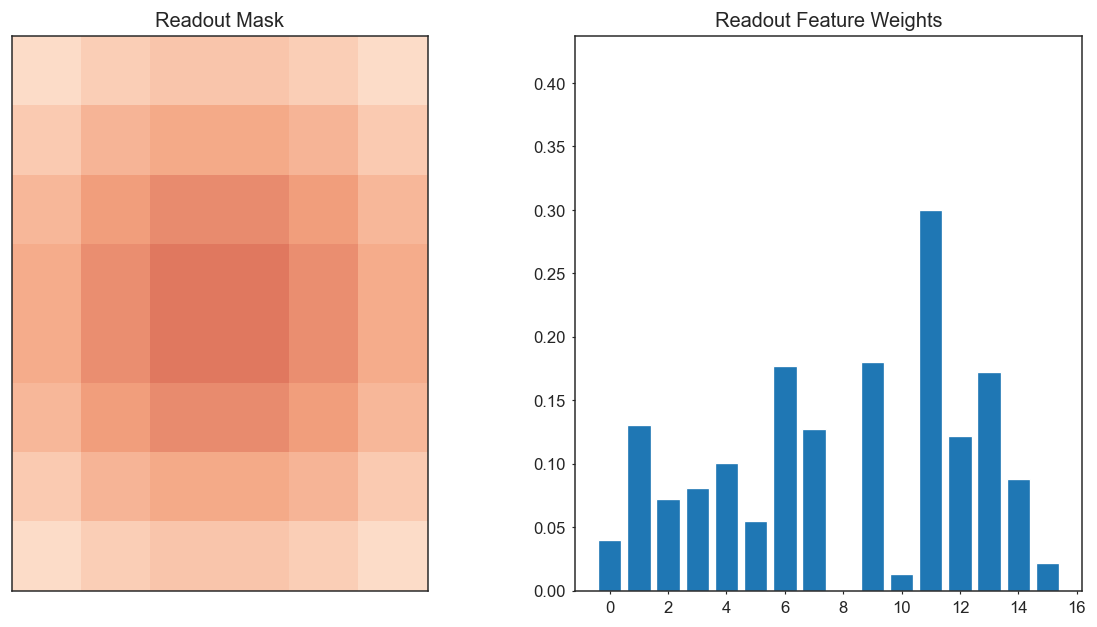

In [127]:
for idx in list(range(0,70,5)):
    print(idx)
    show_weights_all_members(idx,[ensemble_model.members[0].readout[COMPARISON_SESSION_ID]])


0
5
10
15
20
25
30
35
40
45
50
55
60
65


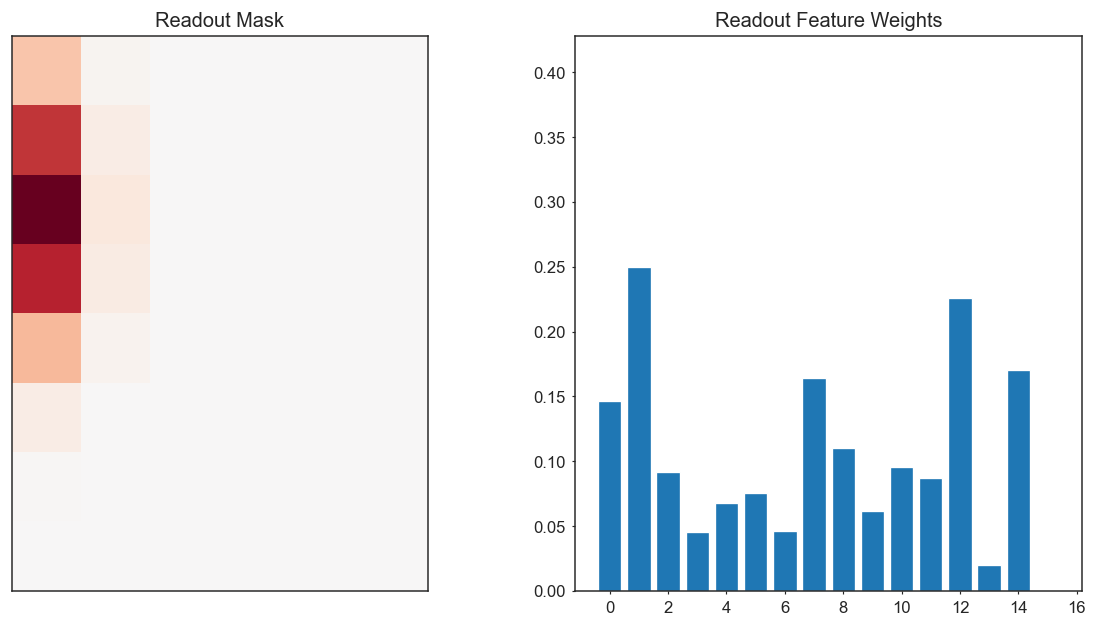

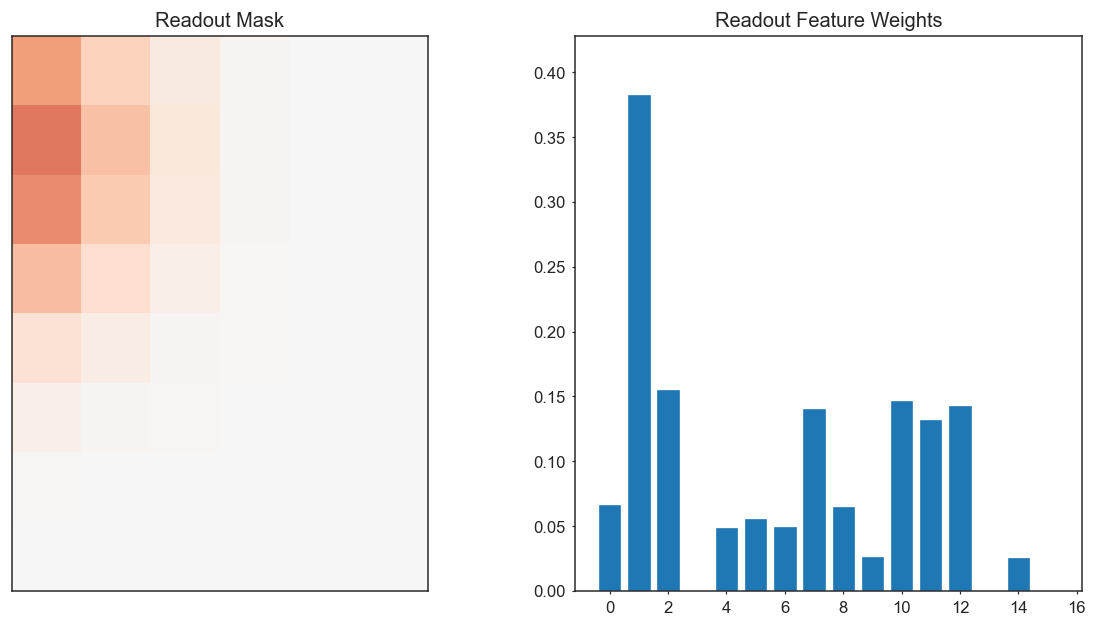

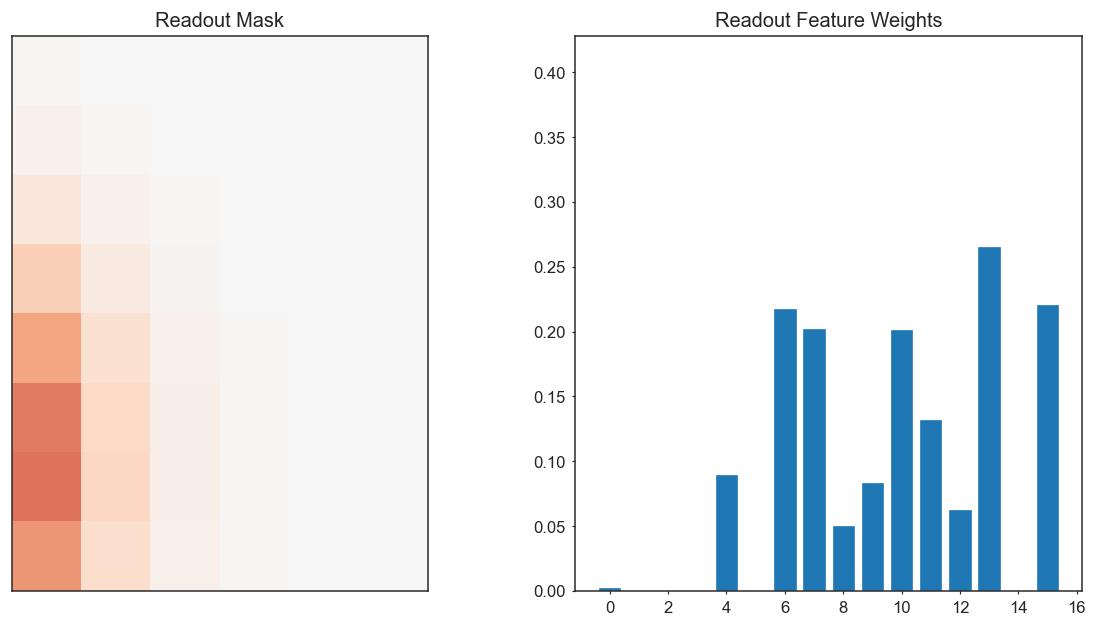

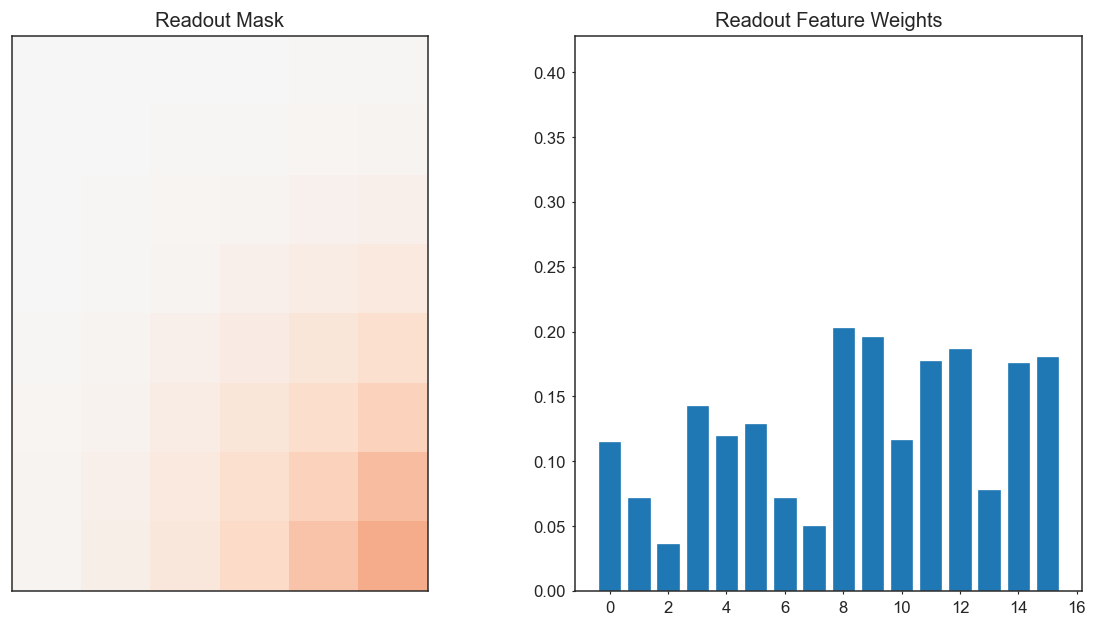

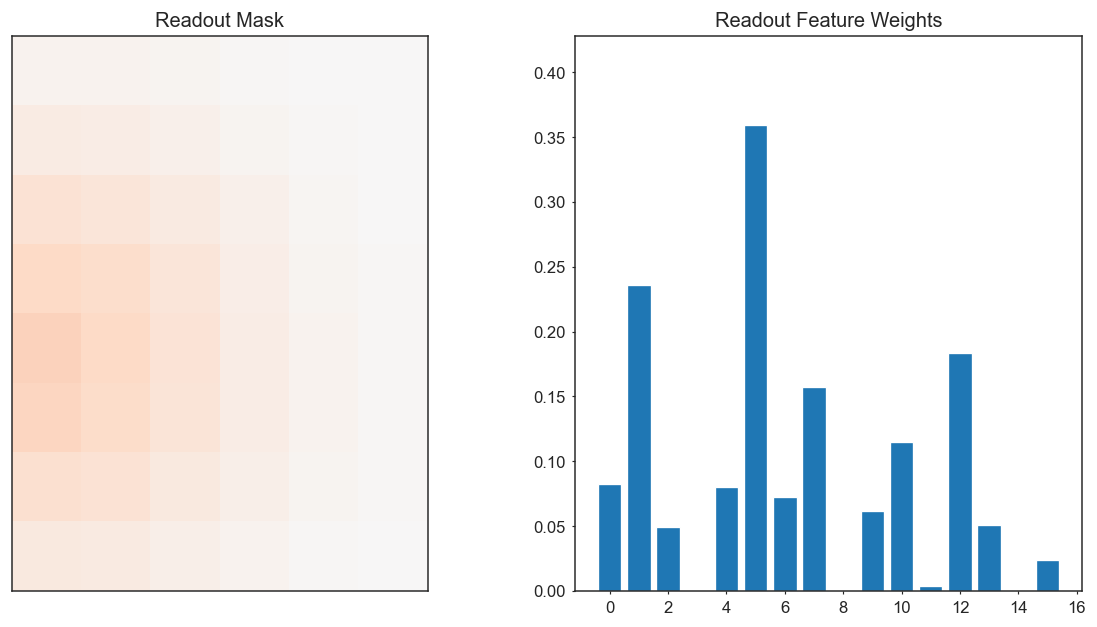

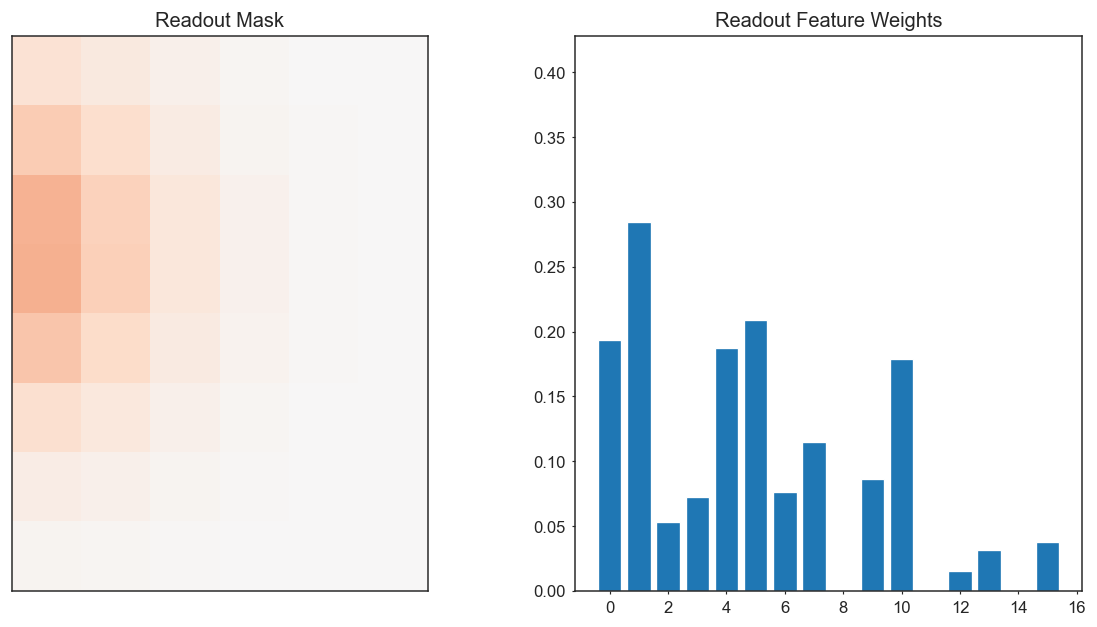

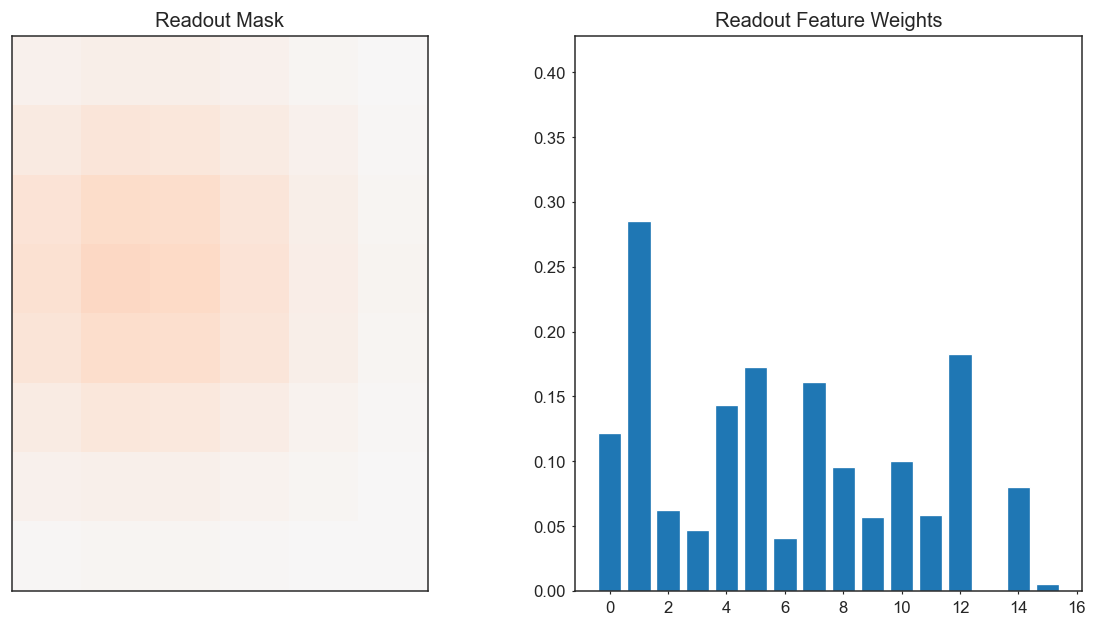

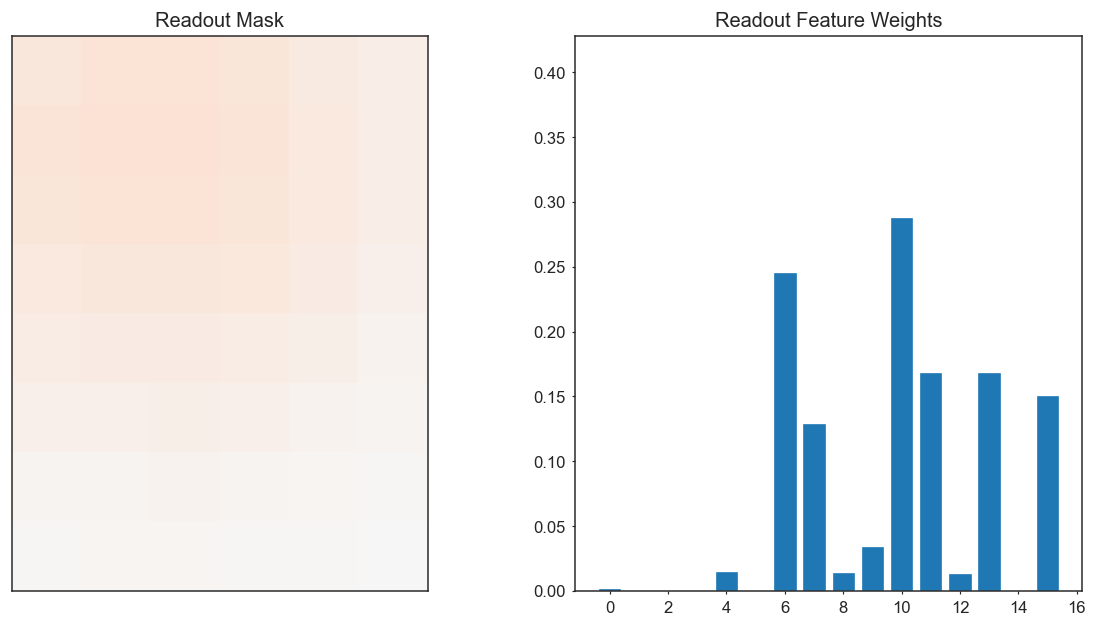

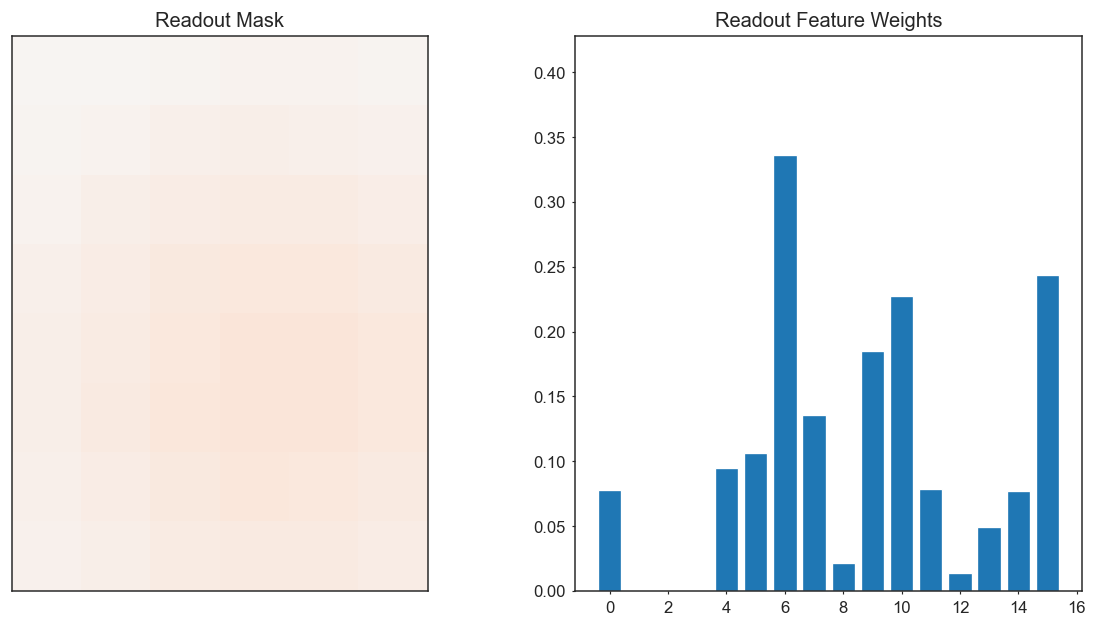

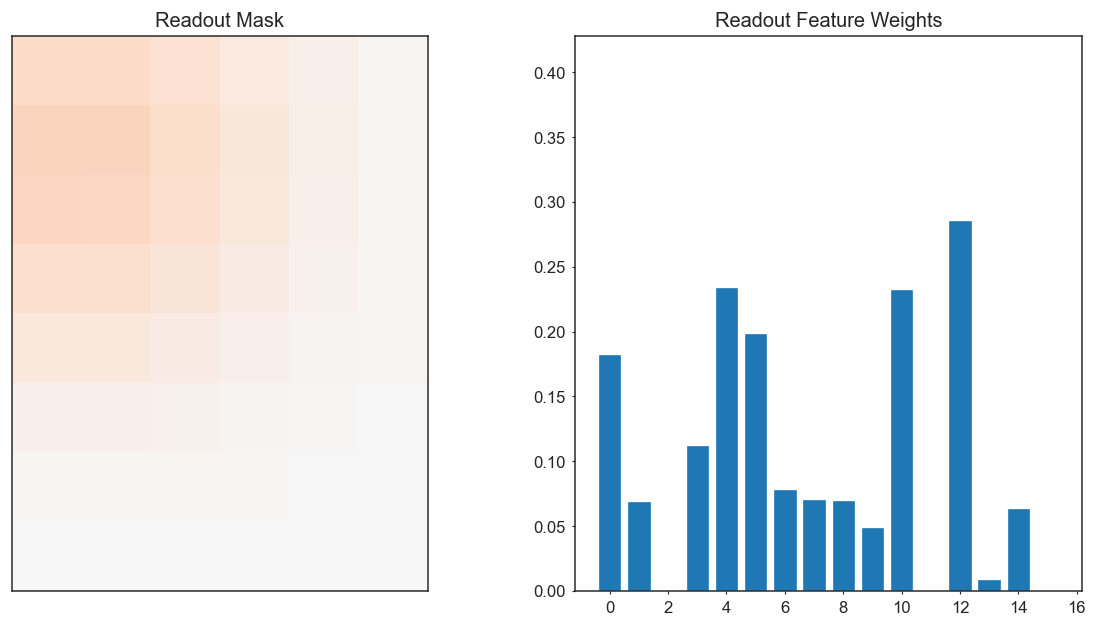

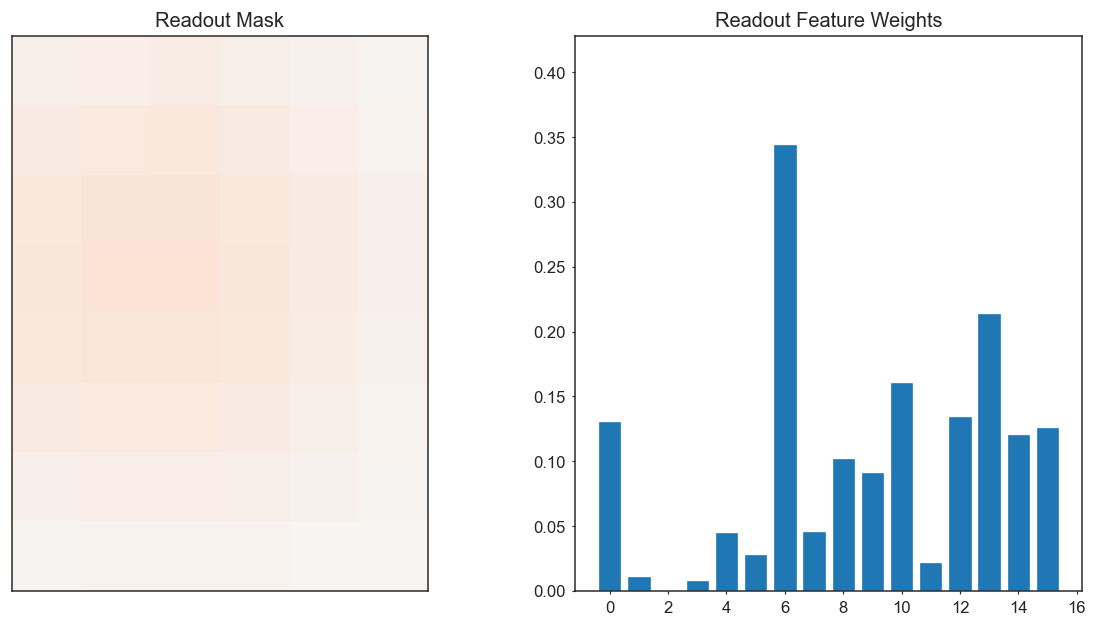

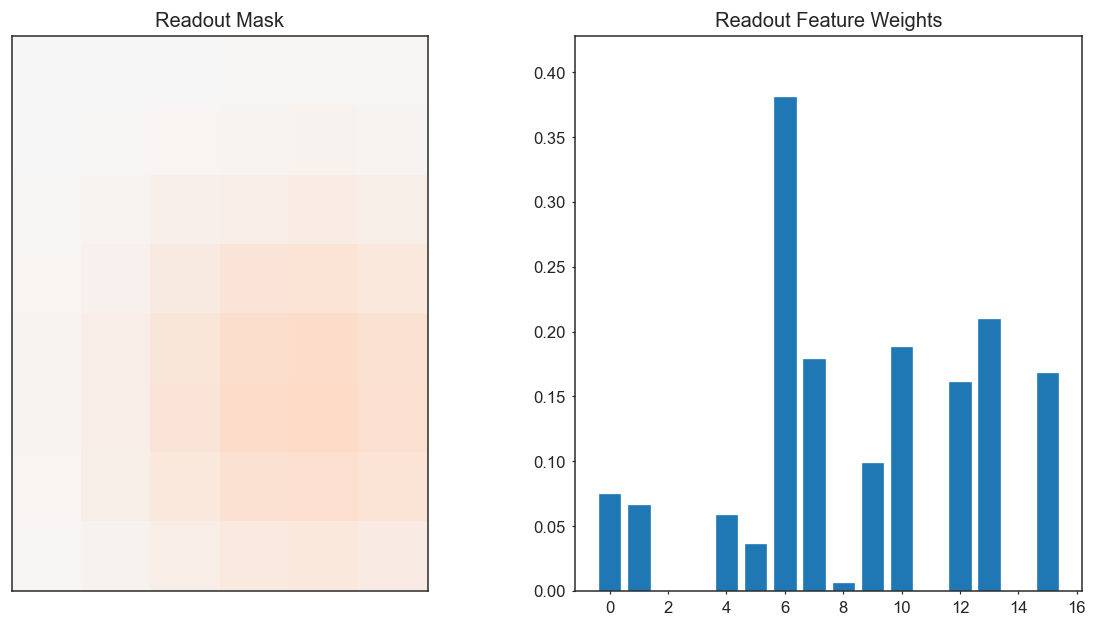

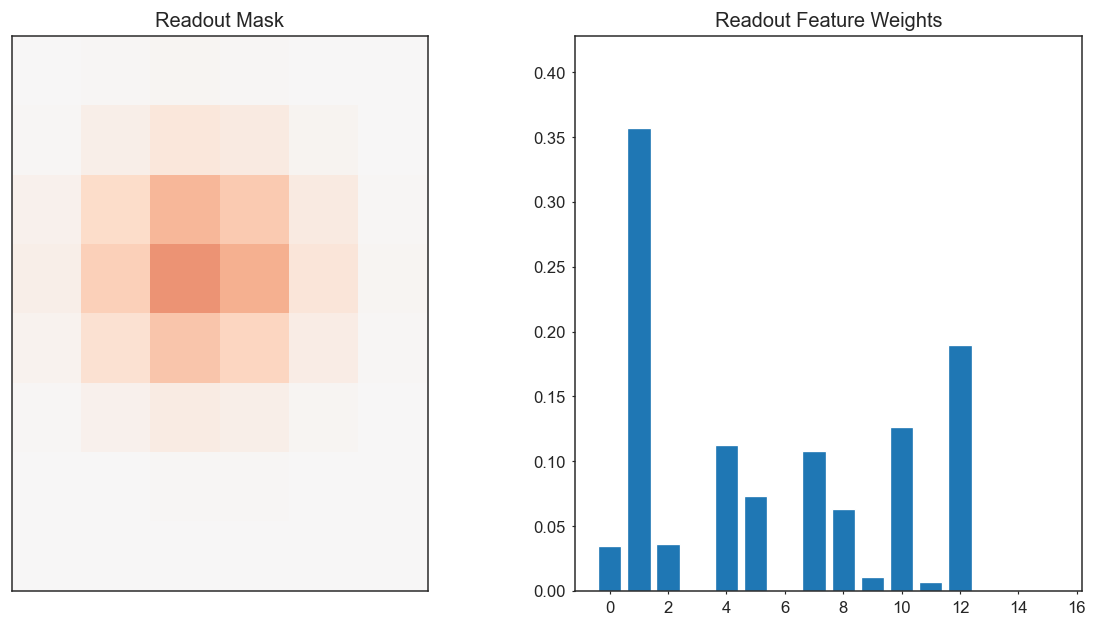

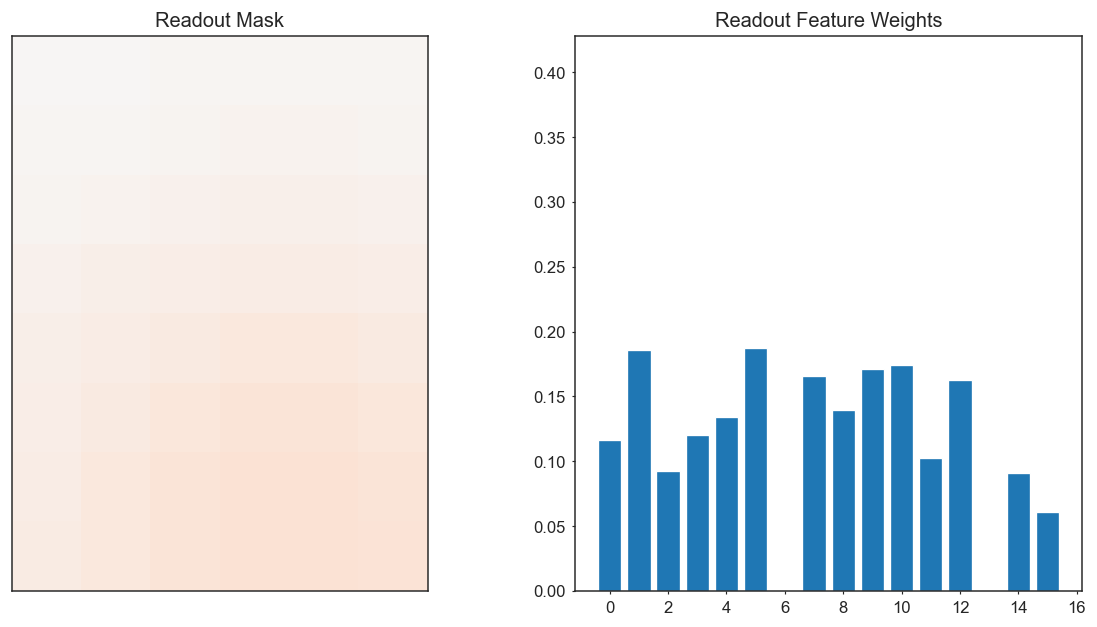

In [111]:
# lets compare ot or_model
for idx in list(range(0,70,5)):
    print(idx)
    show_weights_all_members(idx,[or_model.readout[COMPARISON_SESSION_ID]])

Okay this is interesting, 
- There is large variation between the mask means before centerinf for the individual ensembles
- There is some differences in the log mask var 
- Centering, seems to 

In [120]:
mask, features = fetch_mask_weights(35,or_model.readout[COMPARISON_SESSION_ID])
mask.min()

0.0020523847

In [145]:
or_model.readout[COMPARISON_SESSION_ID].mask_log_var

Parameter containing:
tensor([-0.4996, -0.4111, -0.0837, -0.0835, -0.0503, -0.3504, -0.1636, -0.3539,
        -0.4978,  0.2830, -0.2662, -0.1066, -0.2059,  0.0231, -0.1638, -0.0599,
         0.1166, -0.1372, -0.2106, -0.4493, -0.2294,  0.0048, -0.1885, -0.1551,
        -0.1600, -0.3038, -0.0986, -0.1219, -0.5034, -0.4205, -0.3185, -0.4714,
        -0.3956, -0.1843, -0.2088, -0.1069, -0.5285, -0.1887, -0.1580, -0.1729,
        -0.1007, -0.3449,  0.0173, -0.2414, -0.2826, -0.2272, -0.3035, -0.3236,
         0.1333, -0.1173, -0.1590, -0.1723, -0.2997, -0.2003, -0.0623, -0.2874,
        -0.3257, -0.2064, -0.3126, -0.3772, -0.5618, -0.1914, -0.1879, -0.2159,
        -0.3767, -0.0266, -0.1403, -0.1543, -0.3908, -0.2872, -0.2096, -0.2886,
        -0.3369, -0.3098, -0.2706, -0.0536, -0.3719, -0.2476, -0.0798, -0.3602],
       device='cuda:0', requires_grad=True)

Parameter containing:
tensor([-0.3668, -0.3256, -0.1324, -0.2541,  0.0292, -0.2359, -0.1523,  0.0095,
        -0.3640,  0.1914, -0.1843, -0.1847, -0.1268,  0.1035, -0.1633, -0.0155,
        -0.0510, -0.1166, -0.2955, -0.2905, -0.0879, -0.1290, -0.0710, -0.0827,
        -0.0827, -0.2263, -0.0493, -0.0691, -0.3178, -0.1915, -0.1692, -0.3665,
        -0.2912,  0.0046, -0.0431, -0.0204,  0.0271, -0.1468,  0.0408, -0.0619,
        -0.1280, -0.1847, -0.0663, -0.0216, -0.0734, -0.1030, -0.2716, -0.1619,
         0.1401, -0.1328,  0.0633,  0.0135,  0.0283, -0.1570, -0.0023, -0.1252,
        -0.1045, -0.1554, -0.0675, -0.1711, -0.2950, -0.1952, -0.1127, -0.0688,
        -0.1416, -0.0855, -0.1270, -0.0393, -0.2250, -0.0466, -0.2044, -0.2994,
        -0.1809, -0.1889, -0.0261, -0.0954, -0.1720, -0.2460,  0.0304, -0.1319],
       device='cuda:0')

In [144]:
for mbr_idx in range(n_members):
    mask, features = fetch_mask_weights(sel_readout_idxs[0],ensemble_model.members[mbr_idx].readout[COMPARISON_SESSION_ID])
    print(f"Member {mbr_idx} - Mask min: {mask.min()}, Mask max: {mask.max()}")
    print(f"Mask mean before centering: {[mask_means_precenter[mbr_idx][idx].detach().cpu().numpy() for idx in sel_readout_idxs]}")

    all_vars = ensemble_model.members[mbr_idx].readout[COMPARISON_SESSION_ID].mask_log_var
    print(f"Mask log var before centering: {[all_vars[idx].detach().cpu().numpy() for idx in sel_readout_idxs]}")
    print("\n\n")


Member 0 - Mask min: 0.009658662602305412, Mask max: 0.033248189836740494
Mask mean before centering: [array([-0.74772686, -0.2560554 ], dtype=float32), array([0.40244704, 0.23144697], dtype=float32), array([ 0.1531358 , -0.51150453], dtype=float32)]
Mask log var before centering: [array(-0.1216758, dtype=float32), array(-0.14448225, dtype=float32), array(-0.17777899, dtype=float32)]



Member 1 - Mask min: 0.009241899475455284, Mask max: 0.033979542553424835
Mask mean before centering: [array([-0.7256977, -0.1751859], dtype=float32), array([0.3801126 , 0.17094025], dtype=float32), array([ 0.37540114, -0.63085365], dtype=float32)]
Mask log var before centering: [array(-0.1346539, dtype=float32), array(-0.16820762, dtype=float32), array(-0.06412549, dtype=float32)]



Member 2 - Mask min: 0.012521759606897831, Mask max: 0.02897104062139988
Mask mean before centering: [array([-0.18150538,  0.48517972], dtype=float32), array([0.6444788, 0.698243 ], dtype=float32), array([0.7195392 , 0.148

In [139]:
or_model.readout[COMPARISON_SESSION_ID].mask_mean.detach().cpu().numpy()

array([[-6.83921501e-02, -2.71132112e-01],
       [ 2.76762936e-02, -3.72636527e-01],
       [-1.24690451e-01, -3.21014643e-01],
       [-9.55158174e-02, -3.21477056e-01],
       [-5.11661395e-02, -3.00309837e-01],
       [-1.10563941e-01, -1.81406170e-01],
       [-2.11825259e-02, -2.53331780e-01],
       [-1.03766215e-03, -2.47400373e-01],
       [-3.35156806e-02, -1.09078787e-01],
       [-1.32710814e-01, -3.20058055e-02],
       [ 1.03066802e-01, -2.81429589e-01],
       [ 1.28805071e-01, -2.27561221e-01],
       [ 7.44742528e-02, -3.52741063e-01],
       [-1.02448836e-01, -1.84712633e-01],
       [-3.96941565e-02, -1.57561600e-01],
       [ 2.27870539e-01,  2.23340288e-01],
       [-1.46964625e-01, -6.22992963e-02],
       [ 7.98395649e-02, -2.36121535e-01],
       [-3.06219868e-02, -2.40926713e-01],
       [-6.67617396e-02, -1.28652036e-01],
       [ 3.12014688e-02, -1.29084066e-01],
       [ 9.96861160e-02, -2.37628594e-01],
       [ 4.36233506e-02, -1.39061138e-01],
       [ 7.

In [119]:
mask,features = fetch_mask_weights(sel_readout_idxs[0],ensemble_readouts_online_session[0])
mask.min()

0.009925578

In [130]:
mask, features = fetch_mask_weights(0,or_model.readout[COMPARISON_SESSION_ID])
mask.max()

0.28306654

In [131]:
mask, features = fetch_mask_weights(0,ensemble_model.members[0].readout[COMPARISON_SESSION_ID])
mask.max()

0.058516238